# **AFRICAN INSTITUTE FOR MATHEMATICAL SCIENCE - RWANDA**

---
# **Big Data Analytics with Python**
## Assignment 2
---

## <span style="color:green">Student Name : Joachim SINYABE DANBE</span>

# Answer the following questions and provide a report (2 pages maximum) to them.

### <span style="color:red">Note: More than 2 pages report will be rejected </span>

# **Part 1: Load Rwand House Hold Data**
Please [Download data](https://drive.google.com/file/d/15ztOGriS6uGWMhWeBYdqZs3IwdRi4BJG/view?usp=sharing) and decompress it to <span style="color:blue;">Assignment2/Datasets</span>. After decompressing, you will see the actual size of data is around 3GB. You task is to try to import it in Python using Pandas and PySpark report on the execution times.

Below are some variable definitions:
```python
prov_id = {
    1: "Kigali City",
    2: "Southern Province",
    3: "Western Province",
    4: "Northern Province",
    5: "Eastern Province"
}
```

```python
reg_id = {
    # Kigali City
    11: "Nyarugenge",
    12: "Gasabo",
    13: "Kicukiro",
    14: "Kigali Extra Stratum",
    # Southern Province
    21: "Nyanza",
    22: "Gisagara",
    23: "Nyaruguru",
    24: "Huye",
    25: "Nyamagabe",
    # Western Province
    31: "Karongi",
    32: "Ngororero",
    33: "Rutsiro",
    # Northern Province
    41: "Musanze",
    42: "Burera",
    43: "Gicumbi",
    44: "Rulindo",
    # Eastern Province
    51: "Rwamagana",
    52: "Kayonza",
    53: "Nyagatare",
    54: "Gatsibo"
}
```

[Full data description](https://drive.google.com/file/d/1vlX3zNiNnrhyeS_t1dNeP4sUZl1eOlr-/view?usp=sharing)

In [1]:
import pandas as pd
import pyspark
import time 

In [2]:
path = "Assignment2/Datasets/hh_data_ml.csv"

In [58]:
#TODO: use sep="|"
str_pd = time.time()
df_pandas = pd.read_csv(path,sep = "|")
end_pd = time.time()

print(f"import time  using pandas is : {end_pd-str_pd} seconds")

/tmp/ipykernel_4026/3809302204.py:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pandas = pd.read_csv(path,sep = "|")


import time  using pandas is : 41.69032073020935 seconds


In [3]:
from pyspark.sql import SparkSession
# May take awhile locally
spark = SparkSession.builder.appName("Assignment2").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/11/23 23:37:25 WARN Utils: Your hostname, aimsit, resolves to a loopback address: 127.0.1.1; using 10.6.247.128 instead (on interface wlp0s20f3)
25/11/23 23:37:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/23 23:37:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [60]:
spark

In [4]:
#TODO: use sep="|"
str_spark = time.time()
df_spark = spark.read.csv(path, inferSchema = True, header = True, sep = "|")
end_spark = time.time()
print(f"import time using psark is ; {end_spark - str_spark} seconds" )

[Stage 1:=======================================>                 (16 + 7) / 23]

import time using psark is ; 7.439640283584595 seconds


# PySpark Exercises: Household Survey Dataset

Using  **PySpark** attempt the following:

In [5]:
from pyspark.sql.functions import col, countDistinct, avg, count, when, isnan, mean, sum as spark_sum, corr, desc, expr

df_spark.limit(5).toPandas()

25/11/23 23:37:37 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
25/11/23 23:37:38 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , prov_id, reg_id, dist_id, adm4, urban_rural, hh_id, P03, P05, P07M, P07A, P08, lan_spoken_local, lan_spoken_fr, lan_spoken_en, lan_spoken_other, lan_read_write_local, lan_read_write_fr, lan_read_write_en, lan_read_write_other, P21, P22N, P23, P25, P28, P29, change_log
 Schema: _c0, prov_id, reg_id, dist_id, adm4, urban_rural, hh_id, P03, P05, P07M, P07A, P08, lan_spoken_local, lan_spoken_fr, lan_spoken_en, lan_spoken_other, lan_read_write_local, lan_read_write_fr, lan_read_write_en, lan_read_write_other, P21, P22N, P23, P25, P28, P29, change_log
Expected: _c0 but found: 
CSV file: file:///home/guest/Desktop/JSD/Big%20%20Data%20Analytics%20with%20python/Assignment2/Datasets/hh_data_ml.csv


,_c0,prov_id,reg_id,dist_id,adm4,urban_rural,hh_id,P03,P05,P07M,...,lan_read_write_fr,lan_read_write_en,lan_read_write_other,P21,P22N,P23,P25,P28,P29,change_log
0,0,1,11,111,11101,1,11101101010011066020020002,0,1,10,...,1,2,2,1,3,6,,2,24,Sun Feb 12 11:03:02 2023
1,1,1,11,111,11101,1,11101101010011066020020002,1,2,8,...,1,2,2,1,3,6,,2,28,Sun Feb 12 11:03:02 2023
2,2,1,11,111,11101,1,11101101010011066020020002,2,1,3,...,1,1,1,1,5,1,4,1,,Sun Feb 12 11:03:02 2023
3,3,1,11,111,11101,1,11101101010011066020020002,2,1,9,...,1,2,2,1,5,2,4,1,,Sun Feb 12 11:03:02 2023
4,4,1,11,111,11101,1,11101101010011066020240024,0,1,12,...,1,2,2,1,5,1,4,2,25,Sun Feb 12 11:03:02 2023


In [6]:
print("Row count:", df_spark.count())
df = df_spark
df = df.drop("_c0")

Row count: 25674196


In [7]:
df.columns

['prov_id',
 'reg_id',
 'dist_id',
 'adm4',
 'urban_rural',
 'hh_id',
 'P03',
 'P05',
 'P07M',
 'P07A',
 'P08',
 'lan_spoken_local',
 'lan_spoken_fr',
 'lan_spoken_en',
 'lan_spoken_other',
 'lan_read_write_local',
 'lan_read_write_fr',
 'lan_read_write_en',
 'lan_read_write_other',
 'P21',
 'P22N',
 'P23',
 'P25',
 'P28',
 'P29',
 'change_log']

In [8]:
df.printSchema()

root
 |-- prov_id: integer (nullable = true)
 |-- reg_id: integer (nullable = true)
 |-- dist_id: integer (nullable = true)
 |-- adm4: integer (nullable = true)
 |-- urban_rural: integer (nullable = true)
 |-- hh_id: decimal(26,0) (nullable = true)
 |-- P03: integer (nullable = true)
 |-- P05: integer (nullable = true)
 |-- P07M: integer (nullable = true)
 |-- P07A: integer (nullable = true)
 |-- P08: string (nullable = true)
 |-- lan_spoken_local: string (nullable = true)
 |-- lan_spoken_fr: string (nullable = true)
 |-- lan_spoken_en: string (nullable = true)
 |-- lan_spoken_other: string (nullable = true)
 |-- lan_read_write_local: string (nullable = true)
 |-- lan_read_write_fr: string (nullable = true)
 |-- lan_read_write_en: string (nullable = true)
 |-- lan_read_write_other: string (nullable = true)
 |-- P21: string (nullable = true)
 |-- P22N: string (nullable = true)
 |-- P23: string (nullable = true)
 |-- P25: string (nullable = true)
 |-- P28: string (nullable = true)
 |-- P

In [9]:
from pyspark.sql.functions import col, count, avg, col,when

### **Q1. Count households by province and urban/rural status**
- How many households are in each province?
- How are they distributed between urban and rural areas

In [10]:
from pyspark.sql.functions import col, when, lit
from pyspark.sql import functions as F
df = df_spark.filter(col("prov_id").cast("int").isin([1,2,3,4,5]))
df=df.withColumnRenamed("P03", "Relationship") \
                   .withColumnRenamed("P05", "Sex")

df = df.withColumn(
    "province_name",
    when(col("prov_id") == 1, lit("Kigali City"))
    .when(col("prov_id") == 2, lit("Southern Province"))
    .when(col("prov_id") == 3, lit("Western Province"))
    .when(col("prov_id") == 4, lit("Northern Province"))
    .when(col("prov_id") == 5, lit("Eastern Province"))
)
df.groupBy("province_name","prov_id").agg(F.countDistinct("hh_id")).orderBy("prov_id").show()


[Stage 8:===>                                                     (1 + 16) / 17]

+-----------------+-------+---------------------+
|    province_name|prov_id|count(DISTINCT hh_id)|
+-----------------+-------+---------------------+
|      Kigali City|      1|              1716776|
|Southern Province|      2|              1072507|
| Western Province|      3|               995496|
|Northern Province|      4|               763767|
| Eastern Province|      5|               968517|
+-----------------+-------+---------------------+



In [11]:
df = df.withColumn(
    "urban_rural",
    when(col("urban_rural") == 1, lit("Urban"))
    .when(col("urban_rural") == 2, lit("Rural"))
)


df_distinct = df.groupBy("province_name", "prov_id", "urban_rural") \
    .agg(F.countDistinct("hh_id").alias("distinct_households"))


pivot_df = df_distinct.groupBy("province_name", "prov_id") \
    .pivot("urban_rural", ["Urban", "Rural"]) \
    .sum("distinct_households") \
    .orderBy("prov_id")                                  

pivot_df.show(truncate=False)


[Stage 14:====================================================>   (16 + 1) / 17]

+-----------------+-------+------+-------+
|province_name    |prov_id|Urban |Rural  |
+-----------------+-------+------+-------+
|Kigali City      |1      |477779|1238997|
|Southern Province|2      |144386|928121 |
|Western Province |3      |211553|783943 |
|Northern Province|4      |158234|605533 |
|Eastern Province |5      |137336|831181 |
+-----------------+-------+------+-------+



### **Q2. Average age of household members by province**
- Compute the average age of individuals in each province.

In [12]:
from pyspark.sql.functions import col, when, round

df_filtered = df.withColumn(
    "Age", 
    when((col("P08") != "") & (col("P08").rlike("^[0-9]+$")), col("P08").cast("int"))
)

df_filtered.groupBy("province_name").agg(round(avg("Age"),2).alias("avg_age")).show()


[Stage 22:=====================================================>  (22 + 1) / 23]

+-----------------+-------+
|    province_name|avg_age|
+-----------------+-------+
|      Kigali City|  23.91|
|Southern Province|  21.26|
| Western Province|  23.09|
|Northern Province|  21.77|
| Eastern Province|  20.35|
+-----------------+-------+



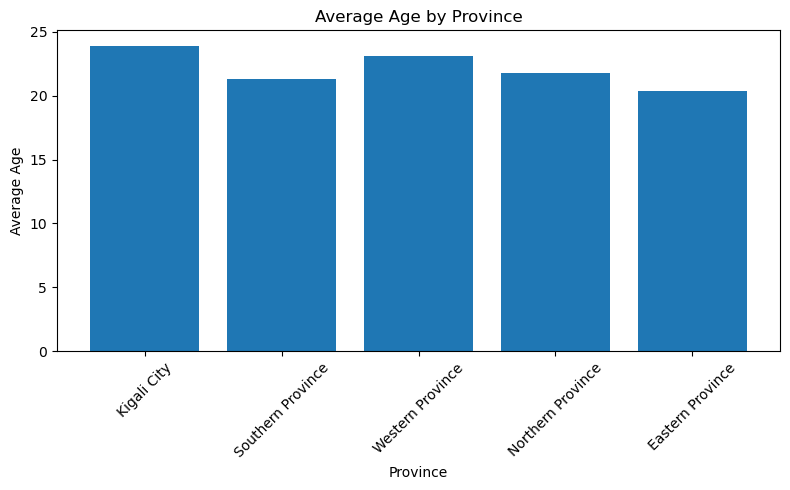

In [13]:
import matplotlib.pyplot as plt
result_df = df_filtered.groupBy("province_name") \
    .agg(round(avg("Age"), 2).alias("avg_age"))

pdf = result_df.toPandas()

# Plot (bar chart)
plt.figure(figsize=(8, 5))
plt.bar(pdf["province_name"], pdf["avg_age"])
plt.xlabel("Province")
plt.ylabel("Average Age")
plt.title("Average Age by Province")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Q3. Gender distribution per district**
- What is the proportion of males and females in each district (`reg_id`)?

In [14]:
from pyspark.sql.functions import col, count, round, when, lit, expr
from pyspark.sql import functions as F

df_gender = df.withColumn("reg_id", col("reg_id").cast("int")) \
              .withColumn("gender", col("Sex").cast("int")) \
              .withColumn("gender_label",
                          when(col("gender") == 1, lit("Male"))
                          .when(col("gender") == 2, lit("Female"))
                          .otherwise(lit("Unknown"))
              )

total_by_district = df_gender.groupBy("reg_id").agg(count("*").alias("total"))

count_gender_district = df_gender.groupBy("reg_id", "gender_label").agg(count("*").alias("count_gender"))

result = count_gender_district.join(total_by_district, "reg_id")
result = result.withColumn(
    "proportion",
    round(col("count_gender") / col("total") * 100, 2)
)


result = result.withColumn(
    "region_name",
    expr("""
        CASE reg_id
            WHEN 11 THEN 'Nyarugenge'
            WHEN 12 THEN 'Gasabo'
            WHEN 13 THEN 'Kicukiro'
            WHEN 14 THEN 'Kigali Extra Stratum'
            WHEN 21 THEN 'Nyanza'
            WHEN 22 THEN 'Gisagara'
            WHEN 23 THEN 'Nyaruguru'
            WHEN 24 THEN 'Huye'
            WHEN 25 THEN 'Nyamagabe'
            WHEN 31 THEN 'Karongi'
            WHEN 32 THEN 'Ngororero'
            WHEN 33 THEN 'Rutsiro'
            WHEN 41 THEN 'Musanze'
            WHEN 42 THEN 'Burera'
            WHEN 43 THEN 'Gicumbi'
            WHEN 44 THEN 'Rulindo'
            WHEN 51 THEN 'Rwamagana'
            WHEN 52 THEN 'Kayonza'
            WHEN 53 THEN 'Nyagatare'
            WHEN 54 THEN 'Gatsibo'
            ELSE 'Unknown'
        END
    """)
)

pivot_multi = result.groupBy("region_name","reg_id") \
    .pivot("gender_label", ["Male", "Female"]) \
    .agg(
        F.first("count_gender").alias("count"),
        F.first("proportion").alias("proportion")
    )

pivot_multi.show(truncate=False)


[Stage 29:================================================>       (20 + 3) / 23]

+--------------------+------+----------+---------------+------------+-----------------+
|region_name         |reg_id|Male_count|Male_proportion|Female_count|Female_proportion|
+--------------------+------+----------+---------------+------------+-----------------+
|Nyarugenge          |11    |1777869   |49.06          |1846056     |50.94            |
|Kicukiro            |13    |453468    |50.47          |445081      |49.53            |
|Musanze             |41    |456039    |49.07          |473273      |50.93            |
|Gisagara            |22    |412492    |49.28          |424624      |50.72            |
|Karongi             |31    |724646    |49.01          |753826      |50.99            |
|Gasabo              |12    |1040910   |50.05          |1038749     |49.95            |
|Huye                |24    |207877    |49.81          |209435      |50.19            |
|Rulindo             |44    |153120    |49.56          |155824      |50.44            |
|Gatsibo             |54    |343


### **Q4. Literacy rates by language**
- What percentage of people can read/write in local language, French, English, and other languages?

In [15]:
from pyspark.sql.functions import col, sum, when, round

df_clean = df.withColumn(
    "lan_read_write_local_bin", when(col("lan_read_write_local") == "1", 1).otherwise(0)
).withColumn(
    "lan_read_write_fr_bin", when(col("lan_read_write_fr") == "1", 1).otherwise(0)
).withColumn(
    "lan_read_write_en_bin", when(col("lan_read_write_en") == "1", 1).otherwise(0)
).withColumn(
    "lan_read_write_other_bin", when(col("lan_read_write_other") == "1", 1).otherwise(0)
)

total_persons = df_clean.count()

result = df_clean.agg(
    round(sum("lan_read_write_local_bin") / total_persons * 100, 2).alias("pct_local"),
    round(sum("lan_read_write_fr_bin") / total_persons * 100, 2).alias("pct_french"),
    round(sum("lan_read_write_en_bin") / total_persons * 100, 2).alias("pct_english"),
    round(sum("lan_read_write_other_bin") / total_persons * 100, 2).alias("pct_other")
)
result.show()

[Stage 40:==============================================>         (19 + 4) / 23]

+---------+----------+-----------+---------+
|pct_local|pct_french|pct_english|pct_other|
+---------+----------+-----------+---------+
|    62.52|     27.54|       9.76|     0.58|
+---------+----------+-----------+---------+



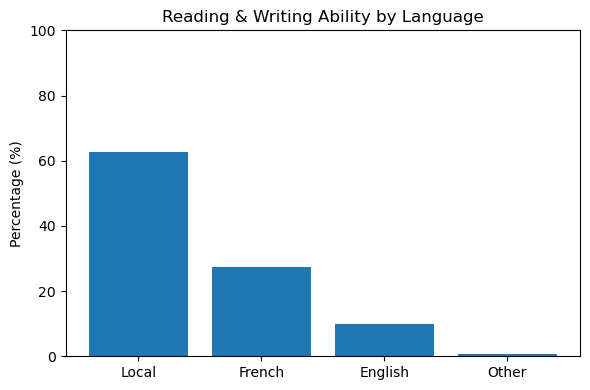

In [18]:
pdf = result.toPandas()
#print(pdf)

values = [
    float(pdf.loc[0, "pct_local"]),
    float(pdf.loc[0, "pct_french"]),
    float(pdf.loc[0, "pct_english"]),
    float(pdf.loc[0, "pct_other"]),
]
labels = ["Local", "French", "English", "Other"]


plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylabel("Percentage (%)")
plt.title("Reading & Writing Ability by Language")
plt.ylim(0, 100)  # optional
plt.tight_layout()
plt.show()



### **Q5. Household size analysis**
- Compute the number of members per household (`hh_id`) and the average household size per province.

In [19]:
hh_size_df = df.groupBy("hh_id").agg(count("*").alias("household_size"))
hh_size_df.show(10, truncate = False)


[Stage 48:==============================================>         (19 + 4) / 23]

+--------------------------+--------------+
|hh_id                     |household_size|
+--------------------------+--------------+
|11101101010011066020760076|4             |
|11101101010021060020690069|7             |
|11101101010031065020820082|6             |
|11101101020011036020300030|6             |
|11101101020011036021030103|4             |
|11101101020011087022540254|4             |
|11101101020021088023100310|4             |
|11101101020021088023740374|5             |
|11101101020021089020190019|4             |
|11101101020021089022400240|4             |
+--------------------------+--------------+
only showing top 10 rows


In [20]:
from pyspark.sql.functions import first, avg

hh_province_df = df.groupBy("hh_id").agg(
    count("*").alias("household_size"),
    first("province_name").alias("province_name")
)

avg_hh_size = hh_province_df.groupBy("province_name").agg(
    round(avg("household_size"), 2).alias("avg_household_size")
)
avg_hh_size.show()


[Stage 53:>                                                       (0 + 16) / 17]

+-----------------+------------------+
|    province_name|avg_household_size|
+-----------------+------------------+
| Western Province|               3.9|
|      Kigali City|              4.24|
|Southern Province|              4.82|
| Eastern Province|              4.34|
|Northern Province|              4.11|
+-----------------+------------------+



### **Q6. Education level distribution**
- How many people attended each level of education (`P21`) per province?

In [21]:
from pyspark.sql.functions import col, when, trim, lit, count


edu_dist_df = df.groupBy("province_name","prov_id" ,"p21").agg(count("*").alias("n_persons"))

df_clean = edu_dist_df.withColumn(
    "p21_clean",
    when(trim(col("p21")) == "", lit(-1))  # -1 pour "Missing"
    .otherwise(col("p21"))
)

df_mapped = df_clean.withColumn(
    "education_label",
    when(col("p21_clean") == -1, lit("Missing"))  
    .when(col("p21_clean") == 0, lit("None"))
    .when(col("p21_clean") == 1, lit("Primary"))
    .when(col("p21_clean") == 2, lit("Secondary"))
    .when(col("p21_clean") == 9, lit("Tertiary"))
    .otherwise(lit("Unknown"))
)

pivot_edu = df_mapped.groupBy("province_name","prov_id") \
    .pivot("education_label", ["None", "Primary", "Secondary", "Tertiary"]) \
    .sum("n_persons") \
    .orderBy("prov_id")  

pivot_edu.show(truncate=False)


[Stage 57:===================================================>    (21 + 2) / 23]

+-----------------+-------+-------+-------+---------+--------+
|province_name    |prov_id|None   |Primary|Secondary|Tertiary|
+-----------------+-------+-------+-------+---------+--------+
|Kigali City      |1      |689510 |4015943|1926393  |54427   |
|Southern Province|2      |1327405|2021248|1318526  |45545   |
|Western Province |3      |603235 |1903852|1015751  |36947   |
|Northern Province|4      |836068 |1244528|763968   |33285   |
|Eastern Province |5      |2069594|909965 |804777   |30956   |
+-----------------+-------+-------+-------+---------+--------+



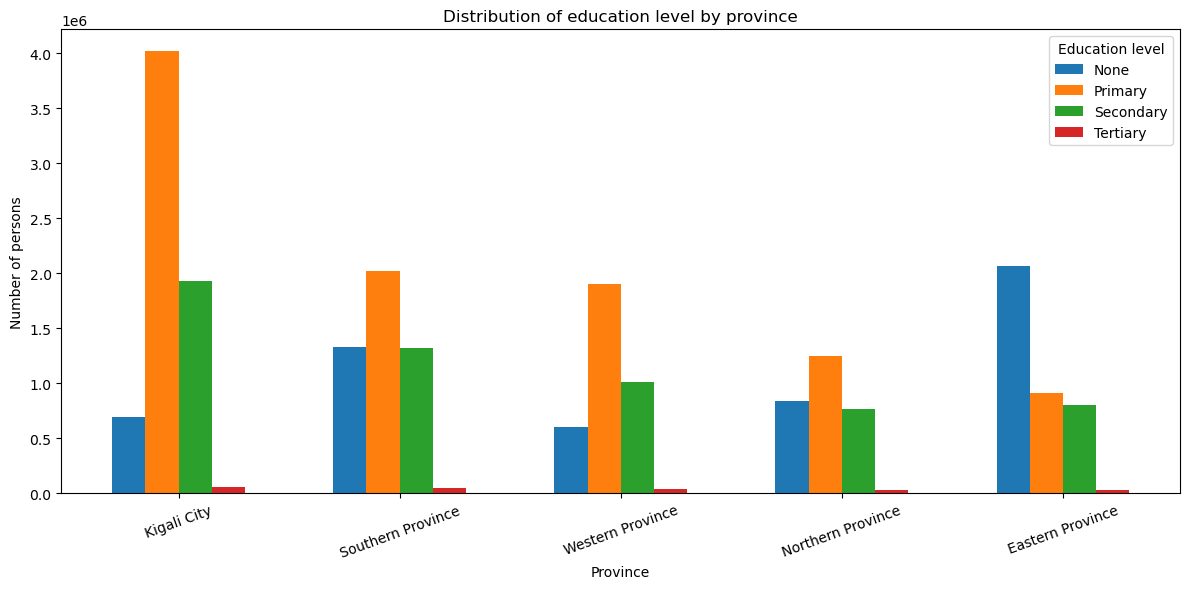

In [22]:
import numpy as np
import matplotlib.pyplot as plt

education_levels = ["None", "Primary", "Secondary", "Tertiary"]

pivot_edu_pd = pivot_edu.toPandas().fillna(0)
pivot_edu_pd = pivot_edu_pd.sort_values("prov_id")
provinces = pivot_edu_pd["province_name"].values

x = np.arange(len(provinces))       # positions des provinces sur l’axe des x
width = 0.15                        # largeur de chaque barre

plt.figure(figsize=(12, 6))

for i, level in enumerate(education_levels):
    plt.bar(
        x + i * width,
        pivot_edu_pd[level].values,
        width=width,
        label=level
    )

plt.xlabel("Province")
plt.ylabel("Number of persons")
plt.title("Distribution of education level by province")
plt.xticks(x + width * (len(education_levels) - 1) / 2, provinces, rotation=20)
plt.legend(title="Education level")
plt.tight_layout()
plt.savefig("graph.png")
plt.show()



### **Q7. Identify households with multilingual members**
- List households where at least one member speaks more than one language.

In [23]:
from pyspark.sql.functions import col, when

df_nlangs = df.withColumn(
    "lan_spoken_local_int", when(col("lan_spoken_local") == "1", 1).otherwise(0)
).withColumn(
    "lan_spoken_fr_int", when(col("lan_spoken_fr") == "1", 1).otherwise(0)
).withColumn(
    "lan_spoken_en_int", when(col("lan_spoken_en") == "1", 1).otherwise(0)
).withColumn(
    "lan_spoken_other_int", when(col("lan_spoken_other") == "1", 1).otherwise(0)
)

df_nlangs = df_nlangs.withColumn(
    "n_lang_spoken",
    col("lan_spoken_local_int") +
    col("lan_spoken_fr_int") +
    col("lan_spoken_en_int") +
    col("lan_spoken_other_int")
)

df_multilinguals = df_nlangs.filter(col("n_lang_spoken") > 1)

households_multi = df_multilinguals.select("hh_id").distinct()
households_multi.show(20, truncate=False)


[Stage 86:===========================================>            (18 + 5) / 23]

+--------------------------+
|hh_id                     |
+--------------------------+
|11101101010011066020760076|
|11101101010021060020690069|
|11101101010031065020820082|
|11101101020011036020300030|
|11101101020011036021030103|
|11101101020011087022540254|
|11101101020021088023740374|
|11101101020021089020190019|
|11101101020031086022240224|
|11101101020031086022260226|
|11101101020031087023090309|
|11101101020041006021080108|
|11101101020041006022080208|
|11101101020041006022940294|
|11101101020041034020860086|
|11101101030011030020970097|
|11101101030011031021780178|
|11101101030011031022620262|
|11101101030011043020680068|
|11101101030011043021100110|
+--------------------------+
only showing top 20 rows


### **Q8. Age vs. education correlation**
- Explore the correlation between age (`P08`) and highest level of education (`P21`).

In [24]:
from pyspark.sql.functions import col, when, trim, regexp_replace

df_age_edu = df.withColumn(
    "P08_clean",
    trim(col("P08"))
).withColumn(
    "P21_clean",
    trim(col("P21"))
)

df_age_edu = df_age_edu.withColumn(
    "age",
    when(df_age_edu["P08_clean"].rlike("^[0-9]+$"), col("P08_clean").cast("int"))
)

df_age_edu = df_age_edu.withColumn(
    "edu_num",
    when(df_age_edu["P21_clean"] == "0", 0)  
    .when(df_age_edu["P21_clean"] == "1", 1)
    .when(df_age_edu["P21_clean"] == "2", 2) 
    .when(df_age_edu["P21_clean"] == "9", 3) 
)

df_corr = df_age_edu.filter(
    col("age").isNotNull() & col("edu_num").isNotNull()
)
corr_value = df_corr.stat.corr("age", "edu_num")
print(f"Pearson correlation between age and education level = {corr_value:.4f}")


[Stage 89:=====================================================>  (22 + 1) / 23]

Pearson correlation between age and education level = -0.2624


 ### **Q9. Most common occupations per province**
- Find the top 5 occupations (`P29`) in each province.

In [25]:
from pyspark.sql.window import Window

from pyspark.sql.functions import col, when, trim, lit, count, row_number

df_clean = df.withColumn(
    "p29_clean",
    when(trim(col("p29")) == "", lit("Missing"))
    .otherwise(col("p29"))
)

job_counts = df_clean.groupBy("province_name", "p29_clean").agg(count("*").alias("job_count"))
window = Window.partitionBy("province_name").orderBy(col("job_count").desc())
job_ranked = job_counts.withColumn("rank", row_number().over(window))
top5_jobs = job_ranked.filter(col("rank") <= 5)



top5_no_missing = top5_jobs.filter(col("p29_clean") != "Missing")

top5_no_missing.select("province_name", "p29_clean", "job_count") \
    .orderBy("province_name", "rank") \
    .show(100)

# top5_jobs.select("province_name", "p29_clean", "job_count").orderBy("province_name", "rank").show(100)


[Stage 92:===========================================>            (18 + 5) / 23]

+-----------------+---------+---------+
|    province_name|p29_clean|job_count|
+-----------------+---------+---------+
| Eastern Province|       20|   248135|
| Eastern Province|       18|   238108|
| Eastern Province|       16|   138443|
| Eastern Province|       15|   131017|
|      Kigali City|       20|   473557|
|      Kigali City|       18|   387230|
|      Kigali City|       19|   266870|
|      Kigali City|       22|   229332|
|Northern Province|       20|   209468|
|Northern Province|       18|   195849|
|Northern Province|       16|   109614|
|Northern Province|       19|   107939|
|Southern Province|       20|   354815|
|Southern Province|       18|   310706|
|Southern Province|       19|   162165|
|Southern Province|       17|   145433|
| Western Province|       20|   283368|
| Western Province|       18|   244022|
| Western Province|       19|   148992|
| Western Province|       17|   125271|
+-----------------+---------+---------+



### **10. Data quality check**
- Identify columns with missing or null values.
- Compute the percentage of missing values per column.

In [26]:
from pyspark.sql.functions import isnan, col, when, count

total_count = df_spark.count()
print(f"Total rows : {total_count}")

missing_exprs = []
for col_name, col_type in df_spark.dtypes:
    missing_cond = col(col_name).isNull()

    if col_type == 'string':
        missing_cond = missing_cond | (col(col_name) == " ")

    elif col_type in ['double', 'float']:
        missing_cond = missing_cond | isnan(col(col_name))

    # Spécial pour prov_id : 6 = valeur manquante
    if col_name == "prov_id":
        missing_cond = missing_cond | (col(col_name) == 6)

    col_pct = (count(when(missing_cond, col_name)) / total_count * 100).alias(col_name)
    missing_exprs.append(col_pct)

missing_summary_df = df_spark.select(missing_exprs)

missing_stats_pd = missing_summary_df.toPandas().transpose()
missing_stats_pd.columns = ["Missing percentage"]
missing_stats_pd = missing_stats_pd.sort_values("Missing percentage", ascending=False)

print("Missing percentage by column:")
print(missing_stats_pd.head(20))


Total rows : 25674196


25/11/23 23:41:53 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , prov_id, reg_id, dist_id, adm4, urban_rural, hh_id, P03, P05, P07M, P07A, P08, lan_spoken_local, lan_spoken_fr, lan_spoken_en, lan_spoken_other, lan_read_write_local, lan_read_write_fr, lan_read_write_en, lan_read_write_other, P21, P22N, P23, P25, P28, P29, change_log
 Schema: _c0, prov_id, reg_id, dist_id, adm4, urban_rural, hh_id, P03, P05, P07M, P07A, P08, lan_spoken_local, lan_spoken_fr, lan_spoken_en, lan_spoken_other, lan_read_write_local, lan_read_write_fr, lan_read_write_en, lan_read_write_other, P21, P22N, P23, P25, P28, P29, change_log
Expected: _c0 but found: 
CSV file: file:///home/guest/Desktop/JSD/Big%20%20Data%20Analytics%20with%20python/Assignment2/Datasets/hh_data_ml.csv
[Stage 101:====================================================>  (22 + 1) / 23]

Missing percentage by column:
                      Missing percentage
P29                            59.719222
P25                            56.259000
P28                            33.614346
P22N                           31.086742
P23                            14.433959
lan_spoken_other                8.436603
lan_spoken_en                   8.436568
lan_spoken_fr                   8.436537
lan_spoken_local                8.436436
lan_read_write_other            8.434496
lan_read_write_en               8.434426
lan_read_write_fr               8.434406
lan_read_write_local            8.434371
P21                             8.433935
prov_id                         7.843416
P08                             0.003431
P07M                            0.000000
P07A                            0.000000
dist_id                         0.000000
reg_id                          0.000000


In [27]:
spark.stop()

# **Part 2: Machine Learning**
## Music Genre classification

Have you ever wondered what makes us, humans, able to tell apart two songs of different genres? How we do we inherenly know the difference between a pop song and heavy metal? This type of classifcation may seem easy for us, but it's a very difficult challenge for a computer to do. So the question is, could an automatic genre classifcation model be possible?

We will be classifying songs based on a number of characteristics into a set of 23 electronic genres. This technology could be used by an application like Pandora to recommend songs to users or just create meaningful channels. Super fun!

### Dataset
*beatsdataset.csv*
Each row is an electronic music song. The dataset contains 100 song for each genre among 23 electronic music genres, they were the top (100) songs of their genres on November 2016. The 71 columns are audio features extracted of a two random minutes sample of the file audio. These features have been extracted using pyAudioAnalysis (https://github.com/tyiannak/pyAudioAnalysis).

### Your task
Use a classification algorithm that classifies songs into the 23 genres provided. Test out several different models and select the highest performing one. Also play around with feature selection methods and finally try to make a recommendation to a user.  

For the feature selection aspect of this project, you may need to get a bit creative if you want to select features from a non-tree algorithm. I did not go over this aspect of PySpark intentionally in the previous lectures to give you chance to get used to researching the PySpark documentation page. Here is the link to the Feature Selectors section of the documentation that just might come in handy: https://spark.apache.org/docs/latest/ml-features.html#feature-selectors


### Source
https://www.kaggle.com/caparrini/beatsdataset

***We need these libraries and an instance spark***

In [28]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler, VectorSlicer
from pyspark.ml.feature import PCA, UnivariateFeatureSelector
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression, GBTClassifier, LinearSVC, MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
import numpy as np
import pandas as pd
from pyspark.ml.feature import VectorAssembler
spark = SparkSession.builder.appName("MusicGenreClassification").getOrCreate()
spark

***Let's try to know our data byexploring***

In [29]:
beats_df = spark.read.csv("Assignment2/Datasets/beatsdataset.csv", header=True, inferSchema=True)
print("Dataset Overview:")
beats_df = beats_df.drop("_c0")
print(f"Number of rows: {beats_df.count()}")
print(f"Number of columns without the index column : {len(beats_df.columns)}")

beats_df.printSchema()
#beats_df.describe().show()

print("Genre distribution:")
beats_df.groupBy("class").count().orderBy("count", ascending=False).show(23)

Dataset Overview:
Number of rows: 2300
Number of columns without the index column : 72
root
 |-- 1-ZCRm: double (nullable = true)
 |-- 2-Energym: double (nullable = true)
 |-- 3-EnergyEntropym: double (nullable = true)
 |-- 4-SpectralCentroidm: double (nullable = true)
 |-- 5-SpectralSpreadm: double (nullable = true)
 |-- 6-SpectralEntropym: double (nullable = true)
 |-- 7-SpectralFluxm: double (nullable = true)
 |-- 8-SpectralRolloffm: double (nullable = true)
 |-- 9-MFCCs1m: double (nullable = true)
 |-- 10-MFCCs2m: double (nullable = true)
 |-- 11-MFCCs3m: double (nullable = true)
 |-- 12-MFCCs4m: double (nullable = true)
 |-- 13-MFCCs5m: double (nullable = true)
 |-- 14-MFCCs6m: double (nullable = true)
 |-- 15-MFCCs7m: double (nullable = true)
 |-- 16-MFCCs8m: double (nullable = true)
 |-- 17-MFCCs9m: double (nullable = true)
 |-- 18-MFCCs10m: double (nullable = true)
 |-- 19-MFCCs11m: double (nullable = true)
 |-- 20-MFCCs12m: double (nullable = true)
 |-- 21-MFCCs13m: double (nu

In [30]:
beats_df.select("class").distinct().count()

23

***So we have 23 different music gender***

***Missing Values***

In [31]:
from pyspark.sql.functions import col, sum as spark_sum
missing_values = beats_df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in beats_df.columns])
missing_values.show(vertical=True)

-RECORD 0---------------------
 1-ZCRm                 | 0   
 2-Energym              | 0   
 3-EnergyEntropym       | 0   
 4-SpectralCentroidm    | 0   
 5-SpectralSpreadm      | 0   
 6-SpectralEntropym     | 0   
 7-SpectralFluxm        | 0   
 8-SpectralRolloffm     | 0   
 9-MFCCs1m              | 0   
 10-MFCCs2m             | 0   
 11-MFCCs3m             | 0   
 12-MFCCs4m             | 0   
 13-MFCCs5m             | 0   
 14-MFCCs6m             | 0   
 15-MFCCs7m             | 0   
 16-MFCCs8m             | 0   
 17-MFCCs9m             | 0   
 18-MFCCs10m            | 0   
 19-MFCCs11m            | 0   
 20-MFCCs12m            | 0   
 21-MFCCs13m            | 0   
 22-ChromaVector1m      | 0   
 23-ChromaVector2m      | 0   
 24-ChromaVector3m      | 0   
 25-ChromaVector4m      | 0   
 26-ChromaVector5m      | 0   
 27-ChromaVector6m      | 0   
 28-ChromaVector7m      | 0   
 29-ChromaVector8m      | 0   
 30-ChromaVector9m      | 0   
 31-ChromaVector10m     | 0   
 32-Chro

**We don't have a missing value in this dataframe**

***Let prepare our features and label and encode the label***

In [32]:
from pyspark.ml.feature import StringIndexer
class_indexer = StringIndexer(inputCol="class", outputCol="label", handleInvalid="keep")
#beats_df = class_indexer.fit(beats_df).transform(beats_df)

feature_cols = [c for c in beats_df.columns if c not in ['class', 'label']]
feature_cols

['1-ZCRm',
 '2-Energym',
 '3-EnergyEntropym',
 '4-SpectralCentroidm',
 '5-SpectralSpreadm',
 '6-SpectralEntropym',
 '7-SpectralFluxm',
 '8-SpectralRolloffm',
 '9-MFCCs1m',
 '10-MFCCs2m',
 '11-MFCCs3m',
 '12-MFCCs4m',
 '13-MFCCs5m',
 '14-MFCCs6m',
 '15-MFCCs7m',
 '16-MFCCs8m',
 '17-MFCCs9m',
 '18-MFCCs10m',
 '19-MFCCs11m',
 '20-MFCCs12m',
 '21-MFCCs13m',
 '22-ChromaVector1m',
 '23-ChromaVector2m',
 '24-ChromaVector3m',
 '25-ChromaVector4m',
 '26-ChromaVector5m',
 '27-ChromaVector6m',
 '28-ChromaVector7m',
 '29-ChromaVector8m',
 '30-ChromaVector9m',
 '31-ChromaVector10m',
 '32-ChromaVector11m',
 '33-ChromaVector12m',
 '34-ChromaDeviationm',
 '35-ZCRstd',
 '36-Energystd',
 '37-EnergyEntropystd',
 '38-SpectralCentroidstd',
 '39-SpectralSpreadstd',
 '40-SpectralEntropystd',
 '41-SpectralFluxstd',
 '42-SpectralRolloffstd',
 '43-MFCCs1std',
 '44-MFCCs2std',
 '45-MFCCs3std',
 '46-MFCCs4std',
 '47-MFCCs5std',
 '48-MFCCs6std',
 '49-MFCCs7std',
 '50-MFCCs8std',
 '51-MFCCs9std',
 '52-MFCCs10std',


In [33]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
pipeline = Pipeline(stages=[class_indexer, assembler])
data = pipeline.fit(beats_df).transform(beats_df).select("features", "label")

data.printSchema()

root
 |-- features: vector (nullable = true)
 |-- label: double (nullable = false)



In [34]:
data.limit(5).toPandas()

,features,label
0,"[0.136439587512, 0.0888612604609, 3.2012005559...",0.0
1,"[0.117038518483, 0.108389033282, 3.19400106287...",0.0
2,"[0.0853077737447, 0.128525418596, 3.1238373468...",0.0
3,"[0.103049917216, 0.167041735198, 3.15083006899...",0.0
4,"[0.151729948738, 0.148404713864, 3.19449794602...",0.0


***Split data and function evaluation***

In [35]:
train, test = data.randomSplit([0.75, 0.25], seed=42)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)

def train_eval(model, train_set, test_set, name="model"):
    m = model.fit(train_set)
    preds = m.transform(test_set)
    acc = evaluator.evaluate(preds)
    print(f"[{name}] Accuracy = {acc:.4f}")
    return m, preds, acc

***raining Models on ALL Features***

In [36]:
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=100, maxDepth=15, seed=42)
rf_model, rf_preds, rf_acc = train_eval(rf, train, test, "RandomForest")

lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=100, regParam=0.01, family="multinomial")
lr_model, lr_pred, lr_acc = train_eval(lr, train, test, "LogisticRegression")


scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
scaler_model = scaler.fit(train)
train_scaled = scaler_model.transform(train)
test_scaled = scaler_model.transform(test)

#for MLP
input_size = len(feature_cols)
output_size = beats_df.select("class").distinct().count()
layers = [input_size, 256, 128, output_size]

mlp = MultilayerPerceptronClassifier(
    labelCol="label", 
    featuresCol="scaledFeatures", # Use scaled features!
    maxIter=1000, 
    layers=layers, 
    blockSize=128, 
    seed=42
)
mlp_model, mlp_pred, mlp_acc = train_eval(mlp, train_scaled, test_scaled, "MLP (Neural Net)")

25/11/23 23:42:11 WARN DAGScheduler: Broadcasting large task binary with size 1390.8 KiB
25/11/23 23:42:11 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
25/11/23 23:42:12 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB
25/11/23 23:42:13 WARN DAGScheduler: Broadcasting large task binary with size 1035.3 KiB
25/11/23 23:42:14 WARN DAGScheduler: Broadcasting large task binary with size 6.8 MiB
25/11/23 23:42:14 WARN DAGScheduler: Broadcasting large task binary with size 1283.8 KiB
25/11/23 23:42:15 WARN DAGScheduler: Broadcasting large task binary with size 8.6 MiB
25/11/23 23:42:16 WARN DAGScheduler: Broadcasting large task binary with size 1284.4 KiB
25/11/23 23:42:17 WARN DAGScheduler: Broadcasting large task binary with size 11.3 MiB
25/11/23 23:42:18 WARN DAGScheduler: Broadcasting large task binary with size 1283.6 KiB
25/11/23 23:42:19 WARN DAGScheduler: Broadcasting large task binary with size 15.2 MiB
25/11/23 23:42:19 WARN DAGScheduler: 

[RandomForest] Accuracy = 0.5222
[LogisticRegression] Accuracy = 0.4316
[MLP (Neural Net)] Accuracy = 0.4027


***Performing Feature Selection***

In [ ]:
selector = UnivariateFeatureSelector(
    featuresCol="features",
    outputCol="selectedFeatures",
    labelCol="label"
)

selector.setSelectionMode("numTopFeatures")
selector.setSelectionThreshold(25) 
selector.setFeatureType("continuous")
selector.setLabelType("categorical")


sel_model = selector.fit(train)
train_fs = sel_model.transform(train)
test_fs  = sel_model.transform(test)

***Training Models on SELECTED Features*** 

In [ ]:
rf_fs = RandomForestClassifier(labelCol="label", featuresCol="selectedFeatures", numTrees=100, maxDepth=15, seed=42)
rf_model_fs, rf_pred_fs, rf_acc_fs = train_eval(rf_fs, train_fs, test_fs, "RandomForest_FS")


lr_fs = LogisticRegression(labelCol="label", featuresCol="selectedFeatures", maxIter=100, regParam=0.01, family="multinomial")
lr_model_fs, lr_pred_fs, lr_acc_fs = train_eval(lr_fs, train_fs, test_fs, "LogisticRegression_FS")


scaler_fs = StandardScaler(inputCol="selectedFeatures", outputCol="scaledSelectedFeatures", withStd=True, withMean=True)
scaler_fs_model = scaler_fs.fit(train_fs)

train_fs_scaled = scaler_fs_model.transform(train_fs)
test_fs_scaled = scaler_fs_model.transform(test_fs)

input_size_fs = 25 
layers_fs = [input_size_fs, 128, 64, output_size]

mlp_fs = MultilayerPerceptronClassifier(
    labelCol="label", 
    featuresCol="scaledSelectedFeatures", 
    maxIter=1000, 
    layers=layers_fs, 
    blockSize=128, 
    seed=42
)
mlp_fs_model, mlp_fs_pred, mlp_fs_acc = train_eval(mlp_fs, train_fs_scaled, test_fs_scaled, "MLP_FS")

25/11/23 23:43:44 WARN DAGScheduler: Broadcasting large task binary with size 1382.8 KiB
25/11/23 23:43:44 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
25/11/23 23:43:45 WARN DAGScheduler: Broadcasting large task binary with size 4.7 MiB
25/11/23 23:43:45 WARN DAGScheduler: Broadcasting large task binary with size 1158.2 KiB
25/11/23 23:43:46 WARN DAGScheduler: Broadcasting large task binary with size 8.0 MiB
25/11/23 23:43:46 WARN DAGScheduler: Broadcasting large task binary with size 1596.2 KiB
25/11/23 23:43:47 WARN DAGScheduler: Broadcasting large task binary with size 12.5 MiB
25/11/23 23:43:48 WARN DAGScheduler: Broadcasting large task binary with size 1963.3 KiB
25/11/23 23:43:49 WARN DAGScheduler: Broadcasting large task binary with size 18.0 MiB
25/11/23 23:43:50 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/11/23 23:43:51 WARN DAGScheduler: Broadcasting large task binary with size 24.1 MiB
25/11/23 23:43:51 WARN DAGScheduler: Br

[RandomForest_FS] Accuracy = 0.2871
[LogisticRegression_FS] Accuracy = 0.3102


***Top Important Features (from Initial Random Forest)***

In [51]:
importances = rf_model.featureImportances.toArray()
fi_df = pd.DataFrame({"Feature": feature_cols, "Importance": importances})

print(fi_df.sort_values("Importance", ascending=False).head(15))

                   Feature  Importance
70          71-BPMessentia    0.069224
68                  69-BPM    0.038304
0                   1-ZCRm    0.029783
69              70-BPMconf    0.024519
1                2-Energym    0.023386
43            44-MFCCs2std    0.020566
38    39-SpectralSpreadstd    0.019536
42            43-MFCCs1std    0.018083
37  38-SpectralCentroidstd    0.017379
53           54-MFCCs12std    0.016825
47            48-MFCCs6std    0.016554
49            50-MFCCs8std    0.016141
2         3-EnergyEntropym    0.015860
54           55-MFCCs13std    0.015723
8                9-MFCCs1m    0.015560


In [117]:
spark.stop()